<a href="https://colab.research.google.com/github/fiap-ia-2025/phase04-cardioia-cnn/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
# Importação das bibliotecas

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


# 💻 CardioIA – Parte 1: Pré-processamento e Organização das Imagens

## Objetivo

Nesta etapa do projeto CardioIA, foi realizado o processo de preparação de imagens médicas para utilização em modelos de Visão Computacional.

O objetivo é organizar e pré-processar as imagens para que possam ser utilizadas posteriormente no treinamento de Redes Neurais Convolucionais (CNNs), garantindo padronização, qualidade e consistência dos dados.

As etapas realizadas incluem:

- Seleção de um dataset público de imagens médicas;
- Organização dos conjuntos de treino, validação e teste;
- Redimensionamento das imagens;
- Conversão de formato;
- Normalização dos pixels;
- Verificação da estrutura final dos dados.

In [50]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [51]:
# Definir caminhos

base_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Treino:", train_dir)
print("Validação:", val_dir)
print("Teste:", test_dir)

Treino: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Validação: /kaggle/input/chest-xray-pneumonia/chest_xray/val
Teste: /kaggle/input/chest-xray-pneumonia/chest_xray/test


In [52]:
# Verificar estrutura

for pasta in [train_dir, val_dir, test_dir]:
    print(f"\n📂 {os.path.basename(pasta).upper()}")

    for classe in os.listdir(pasta):
        quantidade = len(os.listdir(os.path.join(pasta, classe)))
        print(f"{classe}: {quantidade} imagens")


📂 TRAIN
PNEUMONIA: 3875 imagens
NORMAL: 1341 imagens

📂 VAL
PNEUMONIA: 8 imagens
NORMAL: 8 imagens

📂 TEST
PNEUMONIA: 390 imagens
NORMAL: 234 imagens


## 🔎 Análise Inicial dos Dados

Antes do pré-processamento, foi realizada uma inspeção da estrutura do dataset.

Essa etapa permite verificar:

- Quantidade de imagens por classe;
- Organização das pastas;
- Distribuição entre treino, validação e teste.

Essa verificação é importante para garantir que os dados estejam corretamente organizados para utilização em modelos de aprendizado profundo.

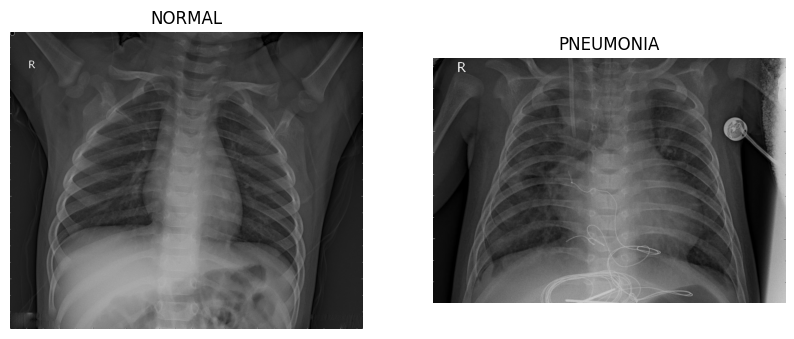

In [53]:
# Visualizar imagens

fig, axes = plt.subplots(1, 2, figsize=(10,5))

classes = ["NORMAL", "PNEUMONIA"]

for ax, classe in zip(axes, classes):

    caminho = os.path.join(train_dir, classe)

    imagem = os.listdir(caminho)[0]

    img = Image.open(os.path.join(caminho, imagem))

    ax.imshow(img, cmap="gray")
    ax.set_title(classe)
    ax.axis("off")

plt.show()

## ⚙️ Pré-processamento das Imagens

Para preparar os dados para utilização em CNNs, foram aplicadas as seguintes etapas:

1. Redimensionamento para 224x224 pixels;
2. Conversão para formato RGB;
3. Organização em lotes (batches);
4. Normalização dos valores dos pixels para a faixa entre 0 e 1.

Essas transformações reduzem variações entre as imagens e garantem compatibilidade com arquiteturas de redes neurais convolucionais.

In [54]:
# Carregar dataset redimensionado

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [55]:
# Normalização

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_norm = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds_norm = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds_norm = test_ds.map(lambda x, y: (normalization_layer(x), y))

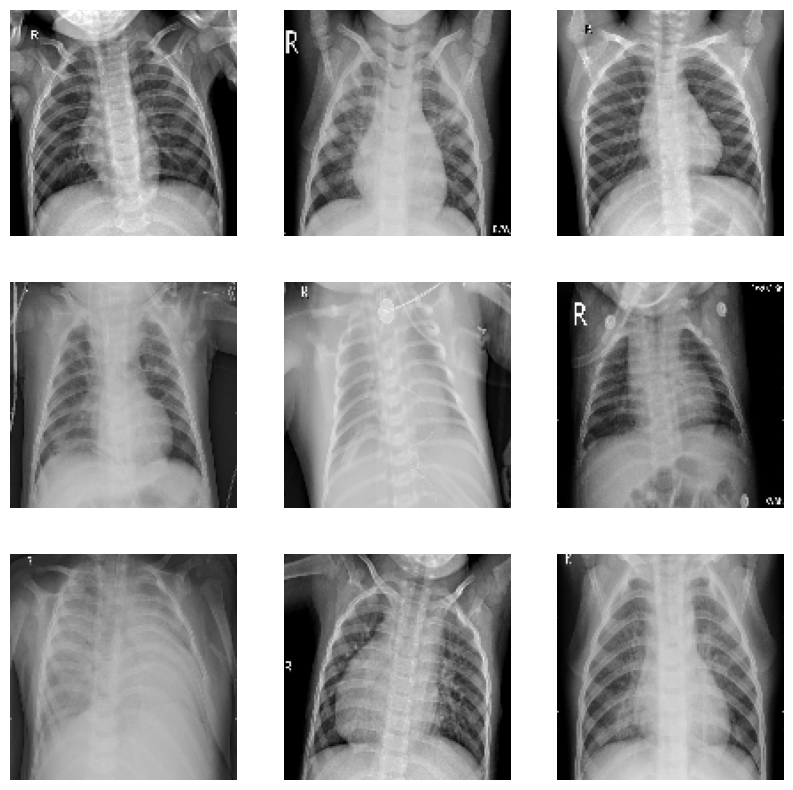

In [56]:
# Visualizar imagens pré-processadas

plt.figure(figsize=(10,10))

for imagens, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(imagens[i].numpy().astype("uint8"))
        plt.axis("off")

plt.show()

In [57]:
# Conferir dimensões

for imagens, labels in train_ds.take(1):

    print("Shape das imagens:", imagens.shape)
    print("Shape dos rótulos:", labels.shape)

Shape das imagens: (32, 128, 128, 3)
Shape dos rótulos: (32,)


## 📊 Distribuição das Classes

A análise da distribuição das classes permite identificar possíveis desbalanceamentos no conjunto de dados.

Essa etapa é importante porque distribuições muito desiguais podem impactar negativamente o desempenho de modelos de aprendizado profundo durante o treinamento.

In [59]:
# Contagem das classes

train_normal = len(os.listdir(os.path.join(train_dir, "NORMAL")))
train_pneumonia = len(os.listdir(os.path.join(train_dir, "PNEUMONIA")))

print(f"NORMAL: {train_normal}")
print(f"PNEUMONIA: {train_pneumonia}")

NORMAL: 1341
PNEUMONIA: 3875


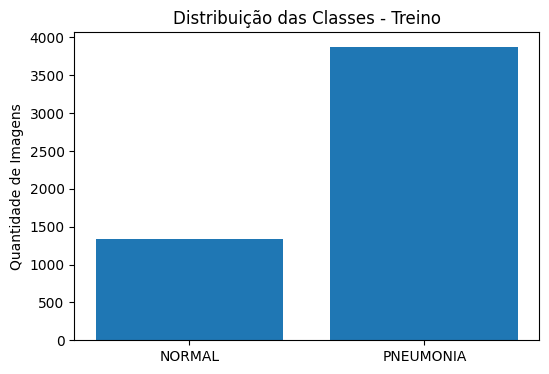

In [60]:
# Gráfico da distribuição

plt.figure(figsize=(6,4))

classes = ["NORMAL", "PNEUMONIA"]
quantidades = [train_normal, train_pneumonia]

plt.bar(classes, quantidades)

plt.title("Distribuição das Classes - Treino")
plt.ylabel("Quantidade de Imagens")

plt.show()

# ✅ Conclusão - Parte 1

Nesta etapa foi realizado o pré-processamento das imagens médicas do dataset Chest X-Ray Images (Pneumonia).

As imagens foram organizadas em conjuntos de treino, validação e teste, redimensionadas para 224x224 pixels, convertidas para o formato RGB e normalizadas para a faixa de valores entre 0 e 1.

Essas etapas garantem a padronização dos dados e preparam o conjunto para utilização em modelos de Redes Neurais Convolucionais (CNNs), que serão desenvolvidos na próxima fase do projeto CardioIA.

# 🤖 Parte 2 – Classificação de Imagens Médicas com CNN

Nesta etapa, as imagens pré-processadas na Parte 1 serão utilizadas para treinar e avaliar modelos de classificação de imagens médicas.

Serão testadas duas abordagens:

1. Uma CNN simples desenvolvida do zero;
2. Um modelo com Transfer Learning, utilizando uma arquitetura pré-treinada.

A avaliação será realizada com métricas como acurácia, matriz de confusão, precisão, recall e F1-score.

In [62]:
# Otimização dos datasets

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 📚 Arquitetura da CNN Simples

A primeira abordagem utiliza uma Rede Neural Convolucional criada do zero. A arquitetura possui três blocos convolucionais, cada um composto por uma camada Conv2D seguida de MaxPooling2D.

Após a extração das características visuais, os dados passam por uma camada Flatten, uma camada densa com 128 neurônios, Dropout para reduzir overfitting e uma camada final com ativação sigmoid, adequada para classificação binária entre NORMAL e PNEUMONIA.

O modelo possui aproximadamente 11 milhões de parâmetros treináveis.

In [63]:
# CNN Simples

model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history_cnn = model_cnn.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.7416 - loss: 0.5794 - val_accuracy: 0.5000 - val_loss: 0.7233
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.7782 - loss: 0.4475 - val_accuracy: 0.5000 - val_loss: 1.1887
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.8505 - loss: 0.3250 - val_accuracy: 0.7500 - val_loss: 0.6428
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.8656 - loss: 0.2997 - val_accuracy: 0.6250 - val_loss: 0.7638
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8738 - loss: 0.2787 - val_accuracy: 0.5625 - val_loss: 1.1354


In [65]:
test_loss, test_acc = model_cnn.evaluate(test_ds_norm)

print(f"Acurácia no teste: {test_acc:.4f}")
print(f"Loss no teste: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 471ms/step - accuracy: 0.6811 - loss: 0.8244
Acurácia no teste: 0.6811
Loss no teste: 0.8244


## 📋 Avaliação da CNN Simples

Após o treinamento, a CNN simples foi avaliada utilizando o conjunto de teste, composto por imagens que não foram utilizadas no treinamento do modelo.

Foram analisadas as seguintes métricas:

- **Acurácia:** proporção total de classificações corretas.
- **Precision:** indica, entre as imagens classificadas como uma determinada classe, quantas realmente pertenciam a ela.
- **Recall:** indica a capacidade do modelo de identificar corretamente os exemplos reais de cada classe.
- **F1-score:** média harmônica entre precision e recall, útil para avaliar o equilíbrio entre essas duas métricas.
- **Matriz de Confusão:** permite visualizar acertos e erros do modelo por classe.

Essas métricas são importantes porque, em aplicações na área da saúde, não basta observar apenas a acurácia geral. É necessário analisar também os tipos de erro cometidos pelo modelo.

In [67]:
# Listas para armazenar valores reais e previsões
y_true = []
y_pred = []
y_prob = []

# Gerar previsões no conjunto de teste
for imagens, labels in test_ds_norm:
    probabilidades = model_cnn.predict(imagens, verbose=0)

    predicoes = (probabilidades > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predicoes.flatten())
    y_prob.extend(probabilidades.flatten())

# Converter para arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Nomes das classes
class_names = ["NORMAL", "PNEUMONIA"]

# Acurácia geral
acc = accuracy_score(y_true, y_pred)

print("="*60)
print("RESULTADOS DA CNN SIMPLES")
print("="*60)
print(f"Acurácia no conjunto de teste: {acc:.4f}")
print("="*60)

RESULTADOS DA CNN SIMPLES
Acurácia no conjunto de teste: 0.6811


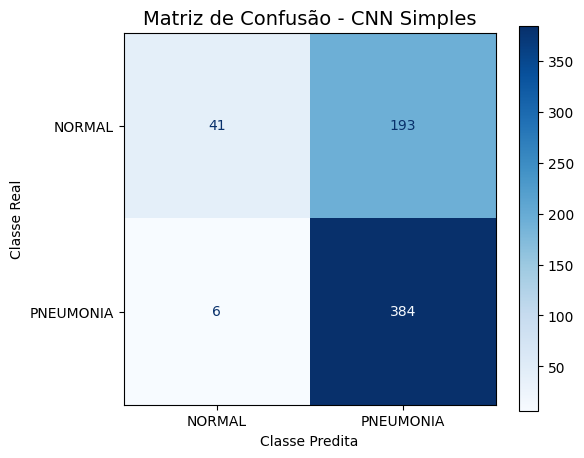

In [68]:
# Matriz de confusão CNN
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Matriz de Confusão - CNN Simples", fontsize=14)
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.grid(False)
plt.show()

In [72]:
# Relatório de classificação
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report_formatado = df_report.copy()

df_report_formatado[["precision", "recall", "f1-score"]] = (
    df_report_formatado[["precision", "recall", "f1-score"]] * 100
)

df_report_formatado = df_report_formatado.round(2)

df_report_formatado

,precision,recall,f1-score,support
NORMAL,87.23,17.52,29.18,234.00
PNEUMONIA,66.55,98.46,79.42,390.00
accuracy,68.11,68.11,68.11,0.68
macro avg,76.89,57.99,54.30,624.00
weighted avg,74.31,68.11,60.58,624.00


## 🧠 Treinamento do Modelo VGG16

Nesta etapa foi utilizada a técnica de Transfer Learning com a arquitetura VGG16 previamente treinada no ImageNet.

As camadas convolucionais do modelo foram congeladas e utilizadas como extratoras de características, enquanto novas camadas densas foram adicionadas para adaptação ao problema de classificação binária entre NORMAL e PNEUMONIA.

O treinamento foi realizado utilizando o conjunto de imagens pré-processadas obtido na Parte 1.

In [73]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

model_vgg = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model_vgg.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [74]:
history_vgg = model_vgg.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=3
)

Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 1051s 6s/step - accuracy: 0.8581 - loss: 0.3300 - val_accuracy: 0.8125 - val_loss: 0.3870
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 1033s 6s/step - accuracy: 0.9279 - loss: 0.1846 - val_accuracy: 1.0000 - val_loss: 0.1660
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 1043s 6s/step - accuracy: 0.9448 - loss: 0.1477 - val_accuracy: 0.7500 - val_loss: 0.3716


## 📈 Avaliação do Modelo VGG16

Após o treinamento utilizando Transfer Learning, o modelo VGG16 foi avaliado por meio do conjunto de teste.

As métricas utilizadas foram:

- Acurácia
- Matriz de Confusão
- Precision
- Recall
- F1-Score

Essas métricas permitem analisar o desempenho do modelo na classificação das imagens médicas e comparar seus resultados com a CNN simples desenvolvida anteriormente.

In [75]:
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_ds_norm)

print("="*60)
print("RESULTADOS DO MODELO VGG16")
print("="*60)
print(f"Acurácia no conjunto de teste: {test_acc_vgg:.4f}")
print(f"Loss no conjunto de teste: {test_loss_vgg:.4f}")
print("="*60)

20/20 ━━━━━━━━━━━━━━━━━━━━ 125s 6s/step - accuracy: 0.7901 - loss: 0.5081
RESULTADOS DO MODELO VGG16
Acurácia no conjunto de teste: 0.7901
Loss no conjunto de teste: 0.5081


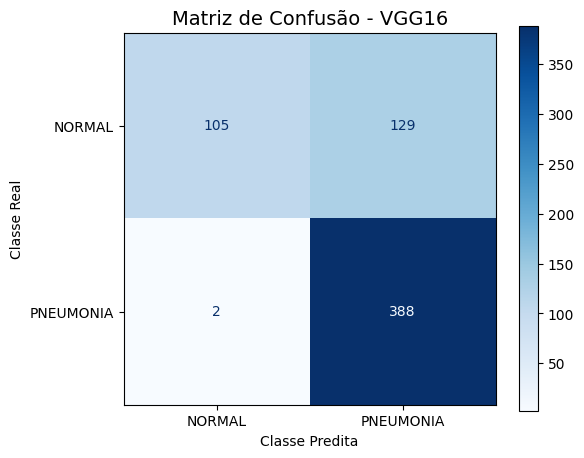

In [81]:
# Matriz de Confusção VGG16

class_names = ["NORMAL", "PNEUMONIA"]

cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_vgg,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Matriz de Confusão - VGG16", fontsize=14)
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.grid(False)

plt.show()

In [79]:
# Métricas de avaliação

y_true_vgg = []
y_pred_vgg = []

for imagens, labels in test_ds_norm:

    pred = model_vgg.predict(imagens, verbose=0)
    pred = (pred > 0.5).astype(int)

    y_true_vgg.extend(labels.numpy())
    y_pred_vgg.extend(pred.flatten())

# Relatório de classificação
report_vgg = classification_report(
    y_true_vgg,
    y_pred_vgg,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True
)

df_report_vgg = pd.DataFrame(report_vgg).transpose()

df_report_vgg_formatado = df_report_vgg.copy()

df_report_vgg_formatado[
    ["precision", "recall", "f1-score"]
] = (
    df_report_vgg_formatado[
        ["precision", "recall", "f1-score"]
    ] * 100
)

df_report_vgg_formatado = df_report_vgg_formatado.round(2)

df_report_vgg_formatado

,precision,recall,f1-score,support
NORMAL,98.13,44.87,61.58,234.00
PNEUMONIA,75.05,99.49,85.56,390.00
accuracy,79.01,79.01,79.01,0.79
macro avg,86.59,72.18,73.57,624.00
weighted avg,83.70,79.01,76.57,624.00


## 💡Interpretação dos Resultados do VGG16

O modelo VGG16 apresentou desempenho superior ao obtido pela CNN simples. A utilização de uma arquitetura previamente treinada permitiu uma extração mais eficiente das características presentes nas radiografias de tórax.

Os resultados demonstram que o Transfer Learning contribuiu para melhorar a capacidade de generalização do modelo, alcançando maior acurácia e melhores métricas de classificação no conjunto de teste.

Essa abordagem mostrou-se mais adequada para o problema proposto, tornando-se o modelo com melhor desempenho entre os experimentos realizados neste projeto.

## 📝 Comparação entre os Modelos

Para avaliar o impacto do uso de Transfer Learning, foram comparados os resultados obtidos pela CNN simples desenvolvida do zero e pelo modelo VGG16 pré-treinado.

A CNN simples apresentou desempenho satisfatório para um protótipo inicial, alcançando acurácia de 68,11% no conjunto de teste. Entretanto, por possuir uma arquitetura mais simples e não utilizar conhecimento prévio, sua capacidade de generalização foi mais limitada.

Por outro lado, o modelo VGG16 obteve acurácia de 79,01%, superando a CNN simples em aproximadamente 11 pontos percentuais. Esse resultado demonstra que o Transfer Learning permitiu uma extração mais eficiente das características visuais presentes nas radiografias de tórax.

Além da melhora na acurácia, o VGG16 apresentou melhor desempenho na identificação de casos de pneumonia, alcançando recall de 99% para essa classe. Esse comportamento é particularmente relevante em aplicações médicas, onde a capacidade de detectar corretamente casos positivos é um fator importante para apoio à decisão clínica.

De forma geral, os resultados indicam que o modelo VGG16 foi a abordagem mais eficiente para o problema proposto, tornando-se a solução com melhor desempenho entre os modelos avaliados.

In [82]:
comparacao = pd.DataFrame({
    "Modelo": ["CNN Simples", "VGG16"],
    "Accuracy (%)": [68.11, 79.01],
    "Arquitetura": [
        "Treinada do zero",
        "Transfer Learning"
    ]
})

comparacao

,Modelo,Accuracy (%),Arquitetura
0,CNN Simples,68.11,Treinada do zero
1,VGG16,79.01,Transfer Learning


A figura abaixo apresenta a comparação da acurácia obtida pelos modelos desenvolvidos durante o projeto. Observa-se que o modelo baseado em Transfer Learning (VGG16) apresentou desempenho superior à CNN simples, alcançando uma melhoria de aproximadamente 11 pontos percentuais na acurácia do conjunto de teste.

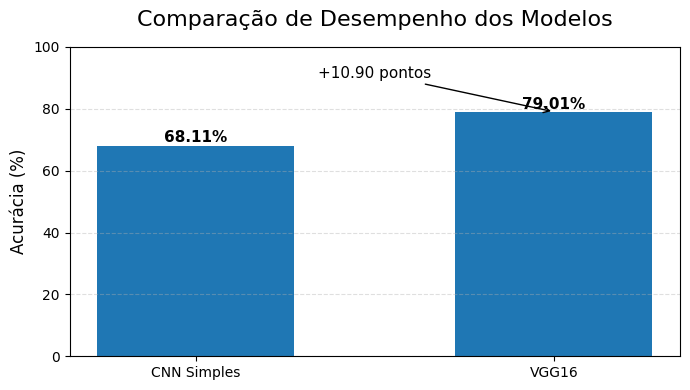

In [86]:
# Gráfico Comparativo

# Dados
modelos = ["CNN Simples", "VGG16"]
acuracias = [68.11, 79.01]

# Figura
plt.figure(figsize=(7, 4))

# Barras
bars = plt.bar(
    modelos,
    acuracias,
    width=0.55
)

# Título
plt.title(
    "Comparação de Desempenho dos Modelos",
    fontsize=16,
    pad=15
)

# Eixo Y
plt.ylabel("Acurácia (%)", fontsize=12)
plt.ylim(0, 100)

# Grade horizontal suave
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Valores nas barras
for bar in bars:
    altura = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + 1,
        f"{altura:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Linha mostrando a melhoria
ganho = acuracias[1] - acuracias[0]

plt.annotate(
    f"+{ganho:.2f} pontos",
    xy=(1, acuracias[1]),
    xytext=(0.5, 90),
    arrowprops=dict(arrowstyle="->"),
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.show()

# ✅ Conclusão - Parte 2

Nesta etapa do projeto CardioIA foram desenvolvidas e avaliadas duas abordagens para classificação de imagens médicas utilizando Redes Neurais Convolucionais (CNNs). A primeira consistiu em uma CNN simples treinada do zero, enquanto a segunda utilizou a técnica de Transfer Learning com a arquitetura VGG16 pré-treinada.

Os resultados demonstraram que ambos os modelos foram capazes de identificar padrões presentes nas radiografias de tórax, porém o modelo VGG16 apresentou desempenho superior. A CNN simples alcançou uma acurácia de 68,11%, enquanto o VGG16 atingiu 79,01% de acurácia no conjunto de teste, evidenciando os benefícios do uso de modelos pré-treinados na extração de características visuais.

Além da melhora na acurácia, o VGG16 apresentou excelentes resultados na identificação de casos de pneumonia, alcançando recall de 99% para essa classe, característica especialmente relevante em aplicações voltadas à área da saúde, onde a detecção correta de possíveis alterações é fundamental.

De modo geral, os experimentos realizados demonstraram a viabilidade da aplicação de técnicas de Visão Computacional e Aprendizado Profundo na análise de exames médicos. Os resultados obtidos reforçam o potencial dessas tecnologias como ferramentas de apoio à decisão clínica, contribuindo para análises mais rápidas, padronizadas e eficientes em contextos de saúde.